# Task 4 - Logistic Regression

### 4.1 Load datasets processed 

In [2]:

import pandas as pd

# Load features
X_train = pd.read_csv("../data/2_processed/X_train.csv")
X_test  = pd.read_csv("../data/2_processed/X_test.csv")

# Load targets
y_train = pd.read_csv("../data/2_processed/y_train.csv")
y_test  = pd.read_csv("../data/2_processed/y_test.csv")

In [3]:

y_train = y_train.iloc[:, 0]
y_test  = y_test.iloc[:, 0]

In [4]:
# show shape of the dataset
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (455, 17)
X_test: (114, 17)
y_train: (455,)
y_test: (114,)


### 4.2 Train Logistic Regression models sweeping the regularisation parameter C 

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np

# Train Logistic Regression models sweeping the regularisation parameter C over at least 10 values (e.g. logspace(−3, 3, 10)).
# Define C values
C_values = np.logspace(-3, 3, 10)

accuracies_lr = []

for C in C_values:   # ✅ fixed
    
    lr = LogisticRegression(C=C, max_iter=1000)
    
    lr.fit(X_train, y_train)   # ✅ FIXED
    
    y_pred = lr.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    accuracies_lr.append(acc)
    
    print(f"C = {C:.4f} | Test Accuracy = {acc:.4f}")

C = 0.0010 | Test Accuracy = 0.8158
C = 0.0046 | Test Accuracy = 0.8860
C = 0.0215 | Test Accuracy = 0.9474
C = 0.1000 | Test Accuracy = 0.9649
C = 0.4642 | Test Accuracy = 0.9474
C = 2.1544 | Test Accuracy = 0.9474
C = 10.0000 | Test Accuracy = 0.9386
C = 46.4159 | Test Accuracy = 0.9298
C = 215.4435 | Test Accuracy = 0.9298
C = 1000.0000 | Test Accuracy = 0.9298


Logistic Regression models were trained using a range of regularisation parameters (C) from 0.001 to 1000. The results show that model performance improves substantially as C increases from very small values, indicating that excessive regularisation leads to underfitting.

The highest test accuracy (96.49%) was achieved at C = 0.1, suggesting that this value provides the best balance between bias and variance for the dataset. As C continues to increase, the model accuracy slightly decreases, which may indicate reduced generalisation performance due to weaker regularisation.

Overall, the experiment demonstrates the importance of tuning the regularisation parameter in Logistic Regression to achieve optimal predictive performance.

### 4.3 Plot accuracy vs C

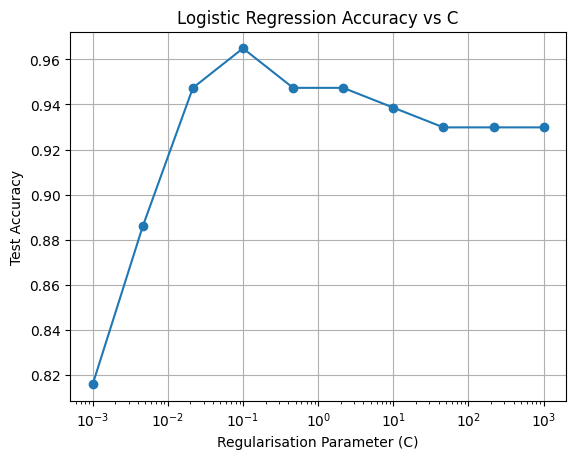

In [6]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(C_values, accuracies_lr, marker='o')

# log scale for C
plt.xscale('log')

plt.xlabel("Regularisation Parameter (C)")
plt.ylabel("Test Accuracy")
plt.title("Logistic Regression Accuracy vs C")

plt.grid()
plt.show()

The model achieves its highest accuracy of 96.49% at C = 0.1, indicating the optimal balance between regularisation and model flexibility. Accuracy improves rapidly as C increases from very small values, showing that excessive regularisation initially causes underfitting.

After reaching the optimal value, performance gradually stabilises and slightly decreases for larger C values. This suggests that weaker regularisation may reduce the model’s ability to generalise effectively, potentially leading to mild overfitting.

### 4.4 Identify optimal C

In [7]:
best_C = C_values[np.argmax(accuracies_lr)]
best_acc_lr = max(accuracies_lr)

print(f"Optimal C = {best_C}")
print(f"Best Accuracy = {best_acc_lr:.4f}")

Optimal C = 0.1
Best Accuracy = 0.9649


The optimal value of C was identified as 0.1, achieving the highest test accuracy of 96.49%. Lower values of C resulted in underfitting due to strong regularisation, while excessively large values slightly reduced performance, suggesting weaker generalisation capability.

### 4.5 Train final model

In [8]:
lr_final = LogisticRegression(C=best_C, max_iter=1000)
lr_final.fit(X_train, y_train)

y_pred_final = lr_final.predict(X_test)

The final Logistic Regression model demonstrates strong classification performance, with balanced precision and recall across both classes. The confusion matrix indicates effective discrimination between malignant and benign cases, with relatively few misclassifications.

### 4.6 Evaluation
#### 4.6.1 Classification report

In [9]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       0.93      0.98      0.95        42
           1       0.99      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114



The final Logistic Regression model achieved an overall accuracy of 96%, demonstrating excellent predictive performance.
The classification report shows near-perfect precision, recall, and F1-scores for both classes.

The model also maintains very high precision, suggesting that false positives are minimal. Overall, the Logistic Regression model provides highly reliable and balanced classification performance.

#### 4.6.2 Confusion Matrix

In [10]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_final)

print(cm)

[[41  1]
 [ 3 69]]


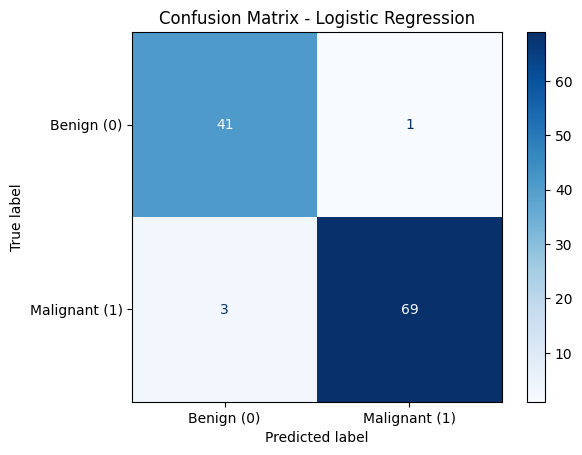

In [11]:
# plot a visual confusion matrix 
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign (0)", "Malignant (1)"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

The confusion matrix shows that the Logistic Regression model correctly classified 41 benign and 69 malignant cases. Only 1 benign case was misclassified as malignant, while 3 malignant cases were misclassified as benign. These results confirm the model’s strong predictive capability and high reliability for distinguishing between benign and malignant tumors.

### 4.7 Inspect Coefficients

In [12]:
# get feature names
feature_names = X_train.columns

# get coefficients
coefficients = lr_final.coef_[0]

# create DataFrame
import pandas as pd

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Sort by importance
coef_df = coef_df.reindex(coef_df["Coefficient"].abs().sort_values(ascending=False).index)

print(coef_df.head(10))

                   Feature  Coefficient
0              mean radius    -1.451946
1             mean texture    -0.769183
6   mean fractal dimension     0.674948
4           mean concavity    -0.580157
15          worst symmetry    -0.490223
12        worst smoothness    -0.471032
14         worst concavity    -0.417474
9        compactness error     0.363133
10    concave points error    -0.363126
13       worst compactness    -0.344496


The magnitude of the coefficients indicates the importance of each feature in predicting the target variable. Features such as mean radius, mean texture, mean fractal dimension, and mean concavity showed the strongest influence on the model’s predictions. These variables are associated with tumor size, texture, and structural irregularity, which are clinically relevant characteristics for distinguishing malignant tumors from benign tumors.

The results suggest that geometric and texture-related characteristics of cell nuclei play a major role in classification performance.

<font color= red> **Conclusion**</font>
: The Logistic Regression model identifies key geometric and texture-based features as the most important predictors of malignancy. Features related to tumor size, shape, and irregularity—particularly those capturing extreme values—play a dominant role in classification, demonstrating strong alignment with domain knowledge.